# Pipeline v4, explained: who is referred, and why

This notebook runs a candidate screening pipeline for university students, **pipeline v4**, on single
12-lead ECGs from the public PTB-XL database, on an ordinary CPU, and shows the explanation that would go
with each referral. A nurse records the ECG; the pipeline decides whether a cardiologist should look at it,
and marks where on the ECG the reason is. Everything is explained below before it is used.

It is a demonstration, not a test: all ECGs shown here belong to the development part of PTB-XL, which was
used while building the pipeline. The numbers that tell how well it works on other data are in section 8.

### What an ECG shows

An ECG records the heart's electrical activity for 10 seconds from electrodes on the limbs and chest. Each
of the 12 **leads** (I, II, III, aVR, aVL, aVF and the chest leads V1-V6) looks at the same activity from a
different direction, so a problem in one wall of the heart shows mostly in some leads. Every heartbeat
draws the same sequence of **waves**: the **P** wave (the atria contract), the **QRS** complex (the
ventricles are activated; it is the tall spike), and the **ST** segment and **T** wave (the ventricles
recover).

### The pieces of the pipeline

1. **Two encoders.** These are large neural networks that other research groups trained on many ECGs to turn
   an ECG into a list of numbers that describe it. They are used as they are, without retraining. The first
   (xECG) turns the 12-lead ECG into 1,024 numbers. The second (ECG-JEPA) cuts 8 of the leads (I, II and
   V1-V6) into 400 pieces, one per lead and 0.2 s *patch*, and describes each piece with 768 numbers; their
   average is a 768-number summary of the whole ECG.
2. **The readout and the ensemble score.** A logistic regression (a weighted sum of the numbers, turned into
   a score) was fitted on thousands of labeled ECGs to tell normal from abnormal, using both summaries. A
   second, small network (the *attention network*, three copies averaged) looks at the 400 pieces one by one
   and decides how much each piece matters. The **ensemble score** is the plain average of the two scores.
   The higher it is, the more abnormal the ECG looks.
3. **Two finding heads.** Two more logistic regressions on the xECG numbers, trained for two findings that the
   general readout can miss: premature ventricular beats (PVC) and Wolff-Parkinson-White (WPW). Each score is
   expressed in standard deviations above healthy ECGs: the **PVC score** and the **WPW score**. The
   **finding score** is the larger of the two.
4. **The referral rule.** An ECG is referred when its ensemble score or its finding score is above a
   threshold. The thresholds are set on healthy ECGs so that only 5% of healthy ECGs are referred (the
   *budget*), and 5% of that budget is kept for the finding score. They come from healthy ECGs because a
   clinic knows how many false alarms it can afford, not how many sick students it will see. A clinic would
   set them on 200 or more of its own students' ECGs read as normal by its cardiologist; here they are set on
   PTB-XL's healthy development ECGs.
5. **The explanation: two maps and a switch.**
   - The **beat-wave map** finds every heartbeat, cuts each beat into its P, QRS, ST and T windows in each of
     the 12 leads, and compares each window with the same window in thousands of healthy beats. A window far
     from its healthy shape is marked in **red**. It says *which beat, which lead and which wave*.
   - The **attention map** shows which of the 400 lead-and-patch pieces pushed the attention network's score
     up most. Those pieces are marked in **blue**. It says *which lead and which 0.2 s moment* the network
     relied on.
   - **The switch.** Premature beats are single odd beats, which the beat-wave map finds well and the
     attention map does not. So if the PVC score is high, the referred ECG is explained by the beat-wave map;
     otherwise by the attention map. Each map marks its pieces above its own threshold, plus its single
     highest piece.

In [1]:
import os
import sys
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = ""

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import json
import time
from concurrent.futures import ThreadPoolExecutor
from io import BytesIO

import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from matplotlib.figure import Figure
from PIL import Image as PILImage

from ecg_experiment.cpu_inference import attention_scores, linear_logit, load_attention_heads, load_jepa_cpu
from ecg_experiment.eda.ptbxl import load_metadata, load_statements
from ecg_experiment.explanation_rule import rule_marks
from ecg_experiment.external_encoders import XECG_DROP_PATH, jepa_input, read_ptb_float64, xecg_input
from ecg_experiment.focal_switch import combined_referral
from ecg_experiment.full_development import cohorts, ptb_table
from ecg_experiment.lead_wave_maps import (
    MINIMUM_BEATS,
    WAVES,
    beat_pieces,
    beat_unit_map,
    fit_wave_references,
    jepa_tokens,
    jepa_unit_map,
    wave_scores,
)
from ecg_experiment.pipeline_v4 import ensemble_logit
from ecg_experiment.pvc_switch import plot_layer_marks, pvc_z, switch_explain
from ecg_experiment.waveforms import LEADS
from ecg_experiment.xecg import DEFAULT_CHECKPOINT_DIR, load_xecg

torch.set_num_threads(4)
print("GPU visible:", torch.cuda.is_available())

COLOURS = [(255, 255, 255), (0, 0, 0), (64, 64, 64), (128, 128, 128), (192, 192, 192), (224, 224, 224),
           (214, 39, 40), (243, 190, 190), (31, 119, 180), (188, 214, 232)]
PALETTE = PILImage.new("P", (1, 1))
PALETTE.putpalette([value for colour in COLOURS for value in colour] + [0] * 3 * (256 - len(COLOURS)))


def display_small(figure: Figure, dpi: int = 50, fixed: bool = True) -> None:
    """Show a figure at low resolution, in a fixed grey, red and blue palette or 16 adaptive colours."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi)
    small = BytesIO()
    image = PILImage.open(buffer).convert("RGB")
    image = (image.quantize(palette=PALETTE, dither=PILImage.Dither.NONE) if fixed
             else image.quantize(colors=16))
    image.save(small, format="png", optimize=True)
    display(Image(small.getvalue()))

GPU visible: False


## 1. The saved scores and the thresholds

The pipeline was already run on all 1,604 development ECGs when it was built; those saved scores are loaded
here (their sources are listed in section 9). They set the thresholds and give the table of section 4. The
thresholds are set on the 463 healthy ECGs of the development set (PTB-XL's "normal" diagnosis only, with
normal sinus rhythm). The PVC-score switch and the two maps' red thresholds were fixed earlier on the same
healthy ECGs; the cell prints what share of the healthy ECGs exceeds each of them.

In [3]:
RUN042 = ROOT / "outputs/experiment042_lead_wave_maps_v1"
RUN043 = ROOT / "outputs/experiment043_ann_heads_v1/stage2"
RUN044 = ROOT / "outputs/experiment044_pipeline_v3_v1"
RUN046 = ROOT / "outputs/experiment046_pipeline_v4_v1"
RUN048 = ROOT / "outputs/experiment048_pvc_switch_v1"
RUN049 = ROOT / "outputs/experiment049_focal_switch_v1"
result042 = json.loads((RUN042 / "result.json").read_text())
result046 = json.loads((RUN046 / "result.json").read_text())
result048 = json.loads((RUN048 / "result.json").read_text())
result049 = json.loads((RUN049 / "result.json").read_text())
with np.load(RUN044 / "pipeline_v3_heads.npz") as saved:
    head_parameters = {name: saved[name] for name in saved.files}
units_saved = np.load(RUN042 / "unit_scores.npz")
attention_saved = np.load(RUN043 / "token_maps.npz")
switch_saved = np.load(RUN048 / "explanations.npz")
findings_saved = np.load(RUN049 / "explanations.npz")
predictions_saved = np.load(RUN046 / "predictions.npz")

groups = cohorts(ptb_table())
table = ptb_table().set_index("ecg_id")
development = groups["development"].set_index("ecg_id")
ids = units_saved["ecg_ids"]
aligned = (np.array_equal(attention_saved["ecg_ids"], ids) and np.array_equal(switch_saved["ecg_ids"], ids)
           and np.array_equal(findings_saved["ecg_ids"], ids)
           and np.array_equal(findings_saved["z_pvc"], switch_saved["z_pvc"])
           and np.array_equal(groups["development"]["ecg_id"].to_numpy(np.int64), ids)
           and np.array_equal(groups["development"].index.to_numpy(dtype=str),
                              predictions_saved["development_record_ids"]))
if not aligned:
    raise ValueError("Saved development rows are not in the same order")

saved_scores = pd.DataFrame({"ensemble": predictions_saved["development_v4_logit"],
                             "pvc": switch_saved["z_pvc"], "wpw": findings_saved["z_wpw"]}, index=ids)
saved_scores["finding"] = saved_scores[["pvc", "wpw"]].max(axis=1)
healthy = [i for i in ids if development.at[i, "original"] and development.at[i, "standard"] == 0]
referred, thresholds = combined_referral(saved_scores["ensemble"].to_numpy(),
                                         saved_scores["finding"].to_numpy(), np.isin(ids, healthy))
saved_scores["referred"] = referred
SWITCH = float(result048["switch_thresholds"]["0.975"])
RED = {1: float(result048["map_thresholds"]["U_B"]), 2: float(result048["map_thresholds"]["attention_jepa"])}
saved_scores["layer"] = np.where(saved_scores["pvc"] > SWITCH, 1, 2)
ENSEMBLE_THRESHOLD, FINDING_THRESHOLD = float(thresholds[0]), float(thresholds[1])
offsets = units_saved["U_B_offsets"]
row_of = {int(i): k for k, i in enumerate(ids)}
worst = {"beat-wave": [units_saved["U_B_scores"][offsets[row_of[i]]:offsets[row_of[i] + 1]].max()
                       for i in healthy],
         "attention": [attention_saved["attention_jepa"][row_of[i]].max() for i in healthy]}
print(f"healthy ECGs: {len(healthy)}")
print(f"referral thresholds: ensemble score {ENSEMBLE_THRESHOLD:.3f}, finding score {FINDING_THRESHOLD:.3f}")
print(f"referred: {int(referred.sum())} of {len(ids)} development ECGs; "
      f"healthy referred: {int(saved_scores.loc[healthy, 'referred'].sum())} of {len(healthy)}")
print(f"switch: PVC score above {SWITCH:.3f}; healthy ECGs above it: "
      f"{(saved_scores.loc[healthy, 'pvc'] > SWITCH).mean():.3f}")
print(f"red thresholds: beat-wave map {RED[1]:.1f}, attention map {RED[2]:.3f}; healthy ECGs with any red: "
      f"beat-wave {np.mean(np.array(worst['beat-wave']) > RED[1]):.3f}, "
      f"attention {np.mean(np.array(worst['attention']) > RED[2]):.3f}")

healthy ECGs: 463
referral thresholds: ensemble score 0.236, finding score 3.336
referred: 813 of 1604 development ECGs; healthy referred: 22 of 463
switch: PVC score above 1.654; healthy ECGs above it: 0.026
red thresholds: beat-wave map 1158.8, attention map 0.275; healthy ECGs with any red: beat-wave 0.052, attention 0.052


With these thresholds an ECG is referred when its ensemble score is above 0.236 or its finding score is above 3.336. They refer 22 of the 463 healthy ECGs (the 5% budget) and 813 of the 1,604 development ECGs. The switch to the beat-wave map needs a PVC score above 1.654, which 2.6% of healthy ECGs reach, and each map's red threshold is a level that 5.2% of healthy ECGs exceed somewhere.

## 2. Loading the pipeline on the CPU

The next cell loads everything a clinic laptop would need, without a graphics card: the two encoders, the
three attention networks, the readout and the two finding heads. It then rebuilds what the beat-wave map
knows about healthy beats: it reads 5,872 healthy ECGs that were used for training (not the development
ECGs shown later), cuts all their beats, and learns, for each of the 48 lead-and-wave combinations (12
leads by 4 waves), what a healthy window looks like and how much it varies. The time is printed.

In [4]:
started = time.perf_counter()
xecg_model = load_xecg(DEFAULT_CHECKPOINT_DIR, device="cpu", backend="vanilla", drop_path_prob=XECG_DROP_PATH)
xecg_model = xecg_model.eval().requires_grad_(False)
jepa_model = load_jepa_cpu()
attention_heads = load_attention_heads(RUN046 / "attention_jepa_weights.npz")
print(f"models loaded in {time.perf_counter() - started:.1f} s")

started = time.perf_counter()
train = groups["train"]
caches = ("outputs/experiment016_xecg_probe_finetune/features",
          "data/processed/pretrained/ecg-jepa-full-public",
          "outputs/experiment004_cpc_40k/released_features")
common = set.intersection(*(set(np.load(ROOT / folder / "ecg_ids.npy").astype(np.int64).tolist())
                            for folder in caches))
fit = train[(train["standard"] == 0) & train["ecg_id"].isin(common)]
with ThreadPoolExecutor(4) as pool:
    cut = pool.map(lambda stem: beat_pieces(read_ptb_float64(stem)), fit["filename_hr"])
    fit_beats = [found for found in cut if len(found[0]) >= MINIMUM_BEATS]
healthy_waves = {name: np.concatenate([pieces[name] for _, pieces in fit_beats]) for name in WAVES}
references = fit_wave_references(healthy_waves)
beats = sum(len(times) for times, _ in fit_beats)
print(f"{len(fit)} healthy training ECGs, {beats} beats (saved count: {result042['arm_b']['fit_beats']}), "
      f"{sum(len(r) for r in references.values())} lead-and-wave references, "
      f"{time.perf_counter() - started:.0f} s")

/home/janetrivera/ecg-cardiopathy-detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


creating xlstm with slstm at:  [0, 1, 4, 5, 8]


models loaded in 4.0 s


5872 healthy training ECGs, 63479 beats (saved count: 63479), 48 lead-and-wave references, 29 s


### How the beat-wave map works, on one ECG

PTB-XL ECG 219 has a premature ventricular beat. First, how the beats of lead II are cut: each colour is one
wave window around a detected beat (P blue, QRS orange, ST green, T purple).

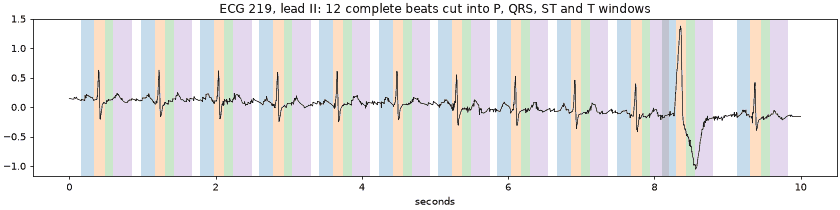

beats found at (s): [0.4, 1.23, 2.04, 2.85, 3.66, 4.48, 5.3, 6.1, 6.91, 7.74, 8.36, 9.37]


In [5]:
EXAMPLE = 219
signal = read_ptb_float64(table.at[EXAMPLE, "filename_hr"])
r_times, pieces = beat_pieces(signal)
colours = {"P": "tab:blue", "QRS": "tab:orange", "ST": "tab:green", "T": "tab:purple"}
figure = Figure(figsize=(12, 3), layout="constrained")
axis = figure.subplots()
axis.plot(np.arange(signal.shape[1]) / 500, signal[1], color="black", linewidth=0.7)
for r_time in r_times:
    for name, (low, high) in WAVES.items():
        axis.axvspan(r_time + low, r_time + high, color=colours[name], alpha=0.25, linewidth=0)
axis.set_title(f"ECG {EXAMPLE}, lead II: {len(r_times)} complete beats cut into P, QRS, ST and T windows")
axis.set_xlabel("seconds")
display_small(figure, dpi=70, fixed=False)
print("beats found at (s):", [round(float(t), 2) for t in r_times])

Now the comparison for one lead and one wave. The grey lines are the lead II QRS of 300 healthy training
beats. The blue lines are this ECG's lead II QRS windows; a window whose distance from the healthy shapes is
above the red threshold is drawn in red.

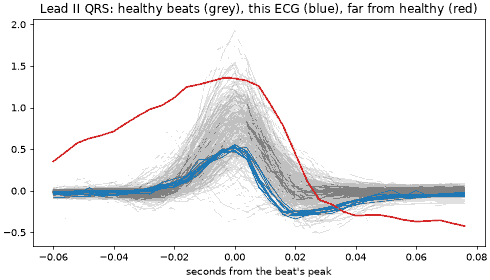

distance of each lead II QRS from the healthy shapes: {0.4: 14, 1.23: 41, 2.04: 77, 2.85: 27, 3.66: 29, 4.48: 23, 5.3: 107, 6.1: 27, 6.91: 10, 7.74: 54, 8.36: 1231, 9.37: 16} | red threshold 1159


In [6]:
rng = np.random.default_rng(0)
figure = Figure(figsize=(7, 4), layout="constrained")
axis = figure.subplots()
times = np.arange(healthy_waves["QRS"].shape[2]) * 2 / 500 + WAVES["QRS"][0]
for row in rng.choice(len(healthy_waves["QRS"]), 300, replace=False):
    axis.plot(times, healthy_waves["QRS"][row, 1], color="grey", alpha=0.15, linewidth=0.7)
example_scores = wave_scores(references, pieces)
for beat in range(len(r_times)):
    score = example_scores[beat, 1, 1]
    odd = score > RED[1]
    axis.plot(times, pieces["QRS"][beat, 1], color="red" if odd else "tab:blue",
              linewidth=1.6 if odd else 0.8)
axis.set_title("Lead II QRS: healthy beats (grey), this ECG (blue), far from healthy (red)")
axis.set_xlabel("seconds from the beat's peak")
display_small(figure, dpi=70)
print("distance of each lead II QRS from the healthy shapes:",
      {round(float(t), 2): round(float(s)) for t, s in zip(r_times, example_scores[:, 1, 1], strict=True)},
      f"| red threshold {RED[1]:.0f}")

**What happened here.** Twelve complete beats were found; the one at 8.36 s comes early and is much taller and wider in lead II. Its QRS window is 1,231 away from the healthy shapes, above the red threshold of 1,159, while the other eleven beats score between 10 and 107. So the map marks this one window, in this one lead, red. The same comparison is made for all 48 lead-and-wave combinations of every beat.

## 3. The whole pipeline on one ECG

One function runs everything on one ECG: it reads the recording, computes both encoders, the attention
networks, the ensemble score, the PVC, WPW and finding scores, cuts the beats for the beat-wave map, applies
the referral rule and the switch, and lists the marks. It also records the differences from the saved
scores of the same ECG (checked in section 7).

In [7]:
WAVE_NAMES = list(WAVES)
checks = []


@torch.inference_mode()
def run_pipeline(ecg_id: int) -> dict:
    """Run pipeline v4 and its explanation on one development ECG, on the CPU."""
    signal = read_ptb_float64(table.at[ecg_id, "filename_hr"])
    pooled, _ = xecg_model(torch.from_numpy(xecg_input(signal)[None]))
    xecg = pooled.float().numpy()
    tokens = jepa_tokens(jepa_model, jepa_input(signal.astype(np.float32))[None], batch=1)
    attention, contributions = attention_scores(attention_heads, tokens)
    readout = linear_logit(head_parameters, "v3", np.concatenate([xecg, tokens.mean(axis=1)], axis=1))
    found = {"ecg_id": ecg_id, "signal": signal, "ensemble": float(ensemble_logit(readout, attention)[0]),
             "pvc": float(pvc_z(head_parameters, xecg)[0]),
             "wpw": float(pvc_z(head_parameters, xecg, "wpw")[0])}
    found["finding"] = max(found["pvc"], found["wpw"])
    found["referred"] = found["ensemble"] > ENSEMBLE_THRESHOLD or found["finding"] > FINDING_THRESHOLD
    r_times, pieces = beat_pieces(signal)
    maps = {1: beat_unit_map(wave_scores(references, pieces), r_times), 2: jepa_unit_map(contributions[0])}
    explanation = switch_explain(maps[1], maps[2], found["pvc"] > SWITCH, RED[1], RED[2])
    found["layer"] = explanation.layer
    found["marks"] = rule_marks(explanation, RED[explanation.layer]) if found["referred"] else []
    row = row_of[ecg_id]
    saved_units = units_saved["U_B_scores"][offsets[row]:offsets[row + 1]]
    checks.append({"ECG": ecg_id,
                   "ensemble score": abs(found["ensemble"] - saved_scores.at[ecg_id, "ensemble"]),
                   "PVC score": abs(found["pvc"] - saved_scores.at[ecg_id, "pvc"]),
                   "WPW score": abs(found["wpw"] - saved_scores.at[ecg_id, "wpw"]),
                   "beat-wave scores": float(np.abs(maps[1].scores - saved_units).max()),
                   "attention map": float(np.abs(contributions[0]
                                                 - attention_saved["attention_jepa"][row]).max()),
                   "same decision": found["referred"] == bool(saved_scores.at[ecg_id, "referred"])})
    found["maps"] = maps
    return found


def describe_marks(found: dict) -> str:
    """Return the marks as lead, wave and beat time (beat-wave map) or lead and patch (attention map)."""
    unit_map = found["maps"][found["layer"]]
    named = []
    for lead, start, end in found["marks"]:
        index = int(np.flatnonzero((unit_map.leads == lead) & np.isclose(unit_map.starts, start))[0])
        if found["layer"] == 1:
            wave = WAVE_NAMES[index % 4]
            named.append(f"{LEADS[lead]} {wave} of the beat at {start - WAVES[wave][0]:.2f} s")
        else:
            named.append(f"{LEADS[lead]} {start:.1f}-{end:.1f} s")
    shown = "; ".join(named[:6])
    return shown + (f"; and {len(named) - 6} more" if len(named) > 6 else "")


def show(ecg_id: int, group: str) -> None:
    """Run the pipeline on one ECG, print its decision and explanation, and plot the marks."""
    found = run_pipeline(ecg_id)
    decision = "REFERRED" if found["referred"] else "not referred"
    print(f"ECG {ecg_id} | {decision} | ensemble score {found['ensemble']:+.2f} "
          f"(threshold {ENSEMBLE_THRESHOLD:+.2f}) | finding score {found['finding']:+.2f} "
          f"(threshold {FINDING_THRESHOLD:.2f}) | PVC score {found['pvc']:+.2f} (switch {SWITCH:.2f})")
    if found["referred"]:
        layer = "beat-wave map (red)" if found["layer"] == 1 else "attention map (blue)"
        print(f"           | explained by the {layer}: {describe_marks(found)}")
    marks = [(lead, start, end, found["layer"]) for lead, start, end in found["marks"]]
    title = f"{group}\nPTB-XL ECG {ecg_id}, {decision}"
    columns = {"red: beat-wave map, blue: attention map": marks}
    figure = plot_layer_marks(found["signal"], 500, columns, title)
    figure.legends.pop()
    display_small(figure)

ECG 219 | REFERRED | ensemble score +0.07 (threshold +0.24) | finding score +6.99 (threshold 3.34) | PVC score +6.99 (switch 1.65)
           | explained by the beat-wave map (red): II QRS of the beat at 8.36 s; aVF QRS of the beat at 8.36 s


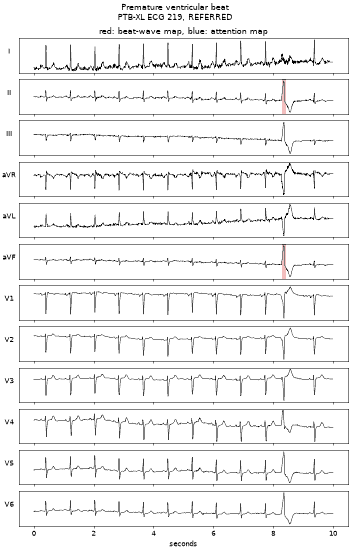

0.49 s for this ECG, plot included


In [8]:
started = time.perf_counter()
show(EXAMPLE, "Premature ventricular beat")
print(f"{time.perf_counter() - started:.2f} s for this ECG, plot included")

**What happened here.** ECG 219 is referred by its finding score, not by its ensemble score: the ensemble score is +0.07, just below its threshold of +0.24, but the finding score (here the PVC score) is 6.99, far above 3.34. Because the PVC score is also above the switch (1.65), the explanation comes from the beat-wave map: two red marks, the QRS of the early beat at 8.36 s in II and in aVF. The whole run, plot included, took well under a second on the CPU (printed below the figure).

## 4. Every development ECG, by group

From the saved scores, over **all** development ECGs of each group: the share referred, the share referred
by the finding score alone, and, among the referred ECGs, the share explained by each map. Groups: the 463
healthy ECGs, benign variants (a normal diagnosis with slow or irregular sinus rhythm), PVC ECGs, and eleven
kinds of cardiopathy from PTB-XL's diagnostic classes. An ECG can belong to several cardiopathy groups.

In [9]:
TEXT = {
    "AMI": "anterior myocardial infarction", "IMI": "inferior myocardial infarction",
    "ISCA": "anterior ischemia",
    "STTC": "non-specific ST/T change", "LVH": "left ventricular hypertrophy",
    "CLBBB": "complete left bundle branch block", "CRBBB": "complete right bundle branch block",
    "IRBBB": "incomplete right bundle branch block",
    "LAFB/LPFB": "left anterior or posterior fascicular block",
    "_AVB": "atrioventricular block", "WPW": "Wolff-Parkinson-White (pre-excitation)",
}
meta, statements = load_metadata(), load_statements()
diagnostic = statements[statements["diagnostic"] == 1]
subclass_of = diagnostic["diagnostic_subclass"].to_dict()
codes = meta["scp_codes"].apply(set)
subclasses = codes.apply(lambda found: {subclass_of[c] for c in found if c in subclass_of})
members = {
    "Healthy": healthy,
    "Benign variant": [i for i in ids if subclasses[i] == {"NORM"}
                       and codes[i] <= {"NORM", "SR", "SBRAD", "SARRH"} and codes[i] & {"SBRAD", "SARRH"}],
    "PVC (premature ventricular beat)": [i for i in ids if "PVC" in codes[i]],
    **{f"{name} ({text})": [i for i in ids if name in subclasses[i]] for name, text in TEXT.items()},
}
summary = {}
for group, found in members.items():
    rows = saved_scores.loc[found]
    chosen = rows[rows["referred"]]
    summary[group] = {"ECGs": len(rows), "referred": rows["referred"].mean(),
                      "by finding score alone": ((rows["finding"] > FINDING_THRESHOLD)
                                                 & (rows["ensemble"] <= ENSEMBLE_THRESHOLD)).mean(),
                      "of referred: beat-wave (red)": (chosen["layer"] == 1).mean()}
    summary[group]["of referred: attention (blue)"] = 1 - summary[group]["of referred: beat-wave (red)"]
display(pd.DataFrame(summary).T.round(2).astype({"ECGs": int}))

,ECGs,referred,by finding score alone,of referred: beat-wave (red),of referred: attention (blue)
Healthy,463,0.05,0.00,0.05,0.95
Benign variant,52,0.08,0.00,0.00,1.00
PVC (premature ventricular beat),84,1.00,0.29,1.00,0.00
AMI (anterior myocardial infarction),229,0.97,0.00,0.52,0.48
IMI (inferior myocardial infarction),227,0.83,0.02,0.48,0.52
ISCA (anterior ischemia),66,0.98,0.00,0.42,0.58
STTC (non-specific ST/T change),152,0.68,0.02,0.35,0.65
LVH (left ventricular hypertrophy),136,0.79,0.00,0.53,0.47
CLBBB (complete left bundle branch block),40,1.00,0.00,0.57,0.43
CRBBB (complete right bundle branch block),37,1.00,0.00,0.43,0.57


**What the table shows.** Every PVC ECG is referred, 29% of them by the finding score alone, and the switch explains all of them with the beat-wave map. Healthy ECGs are referred at the 5% budget and benign variants at 8%, almost all explained by the attention map. The cardiopathy groups are referred between 68% (non-specific ST/T change) and 100% of the time (both complete bundle branch blocks). Between 33% (incomplete right bundle branch block) and 57% (complete left bundle branch block) of each group's referred ECGs are explained by the beat-wave map, because the PVC score is above the switch for many ECGs without a PVC: 52% of the referred anterior infarcts, for example.

In [10]:
def show_group(group: str, count: int) -> None:
    """Show the ``count`` lowest-numbered development ECGs of a group."""
    for ecg_id in sorted(members[group])[:count]:
        show(ecg_id, group)

## 5. Healthy hearts

Four healthy ECGs, then two benign variants. The examples are chosen by a rule, the lowest ECG numbers of
each group, not by hand.

ECG 47 | not referred | ensemble score -4.33 (threshold +0.24) | finding score +1.29 (threshold 3.34) | PVC score +1.18 (switch 1.65)


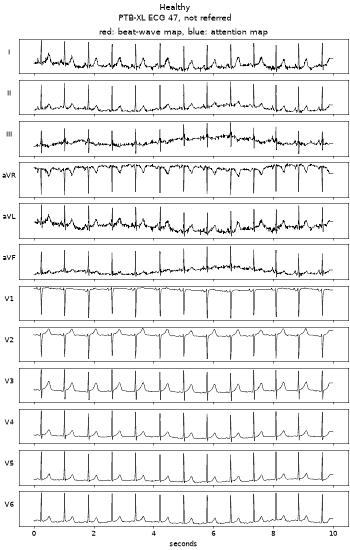

ECG 51 | not referred | ensemble score -4.05 (threshold +0.24) | finding score -0.49 (threshold 3.34) | PVC score -1.27 (switch 1.65)


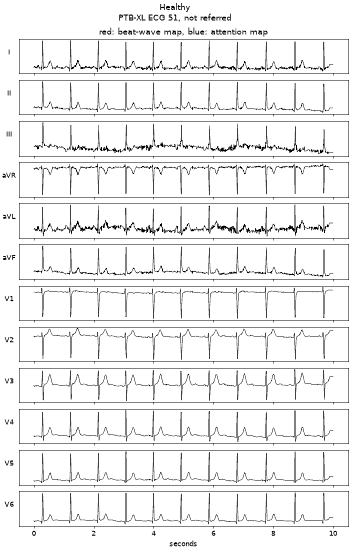

ECG 91 | not referred | ensemble score -5.25 (threshold +0.24) | finding score -0.06 (threshold 3.34) | PVC score -0.06 (switch 1.65)


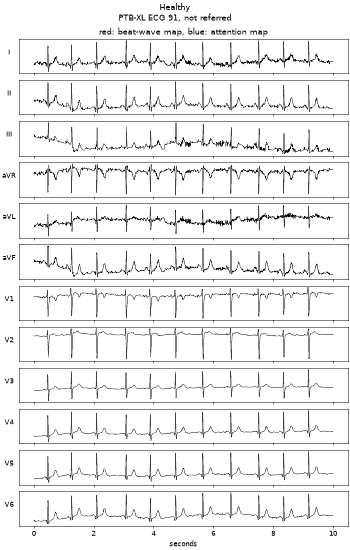

ECG 165 | not referred | ensemble score -4.91 (threshold +0.24) | finding score +1.21 (threshold 3.34) | PVC score +0.17 (switch 1.65)


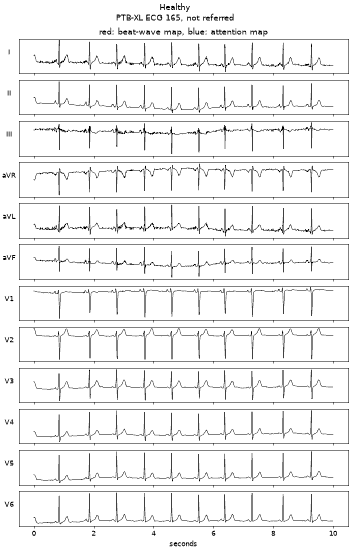

In [11]:
show_group("Healthy", 4)

None of the four healthy ECGs is referred: the ensemble score is between -5.25 and -4.05, far below +0.24, and the finding score is at most 1.29. ECGs that are not referred get no explanation, so their plots have no marks.

ECG 69 | not referred | ensemble score -1.17 (threshold +0.24) | finding score +0.90 (threshold 3.34) | PVC score -0.36 (switch 1.65)


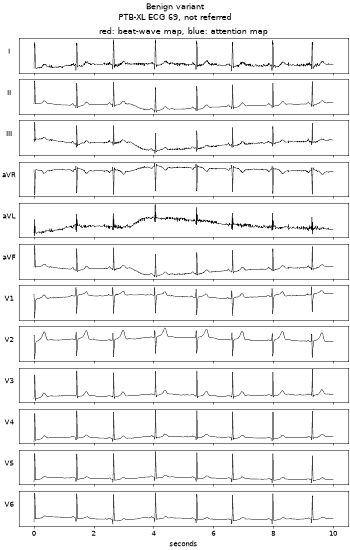

ECG 228 | not referred | ensemble score -4.59 (threshold +0.24) | finding score +0.86 (threshold 3.34) | PVC score +0.41 (switch 1.65)


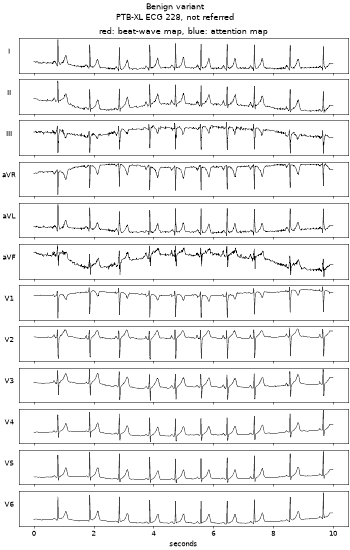

In [12]:
show_group("Benign variant", 2)

Neither benign variant is referred (ensemble scores -1.17 and -4.59). Over all 52 benign variants, 8% are referred (section 4).

## 6. Different cardiopathies

Two ECGs per group, again the lowest-numbered in the development set.

**Premature ventricular beat (PVC).** An early, wide beat that starts in the ventricles instead of following the normal path. The PVC finding head was trained for exactly this.

ECG 219 | REFERRED | ensemble score +0.07 (threshold +0.24) | finding score +6.99 (threshold 3.34) | PVC score +6.99 (switch 1.65)
           | explained by the beat-wave map (red): II QRS of the beat at 8.36 s; aVF QRS of the beat at 8.36 s


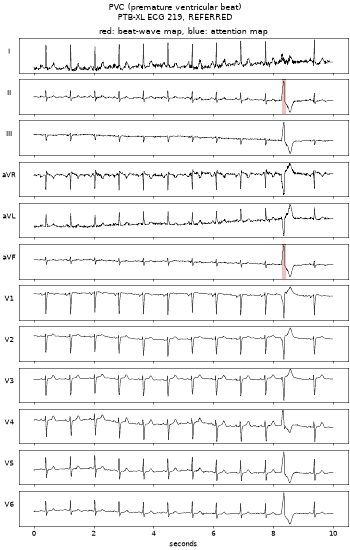

ECG 287 | REFERRED | ensemble score +8.29 (threshold +0.24) | finding score +6.94 (threshold 3.34) | PVC score +6.94 (switch 1.65)
           | explained by the beat-wave map (red): V1 ST of the beat at 9.10 s


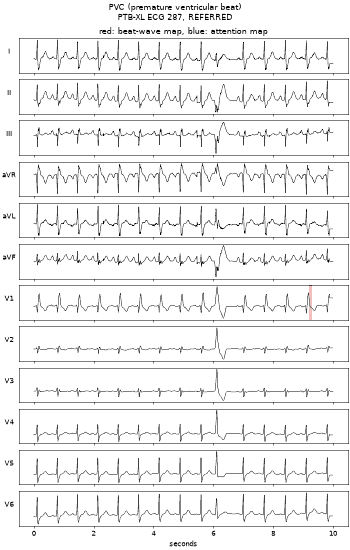

In [13]:
show_group("PVC (premature ventricular beat)", 2)

Both PVC examples are referred and explained by the beat-wave map, ECG 219 as in section 3. ECG 287, which also has a complete left bundle branch block, gets one red mark, the ST of the beat at 9.10 s in V1.

**Anterior myocardial infarction.** Damage to the front wall of the heart, expected in the chest leads V1-V4.

ECG 184 | REFERRED | ensemble score +7.02 (threshold +0.24) | finding score +1.71 (threshold 3.34) | PVC score +1.71 (switch 1.65)
           | explained by the beat-wave map (red): aVL P of the beat at 6.46 s


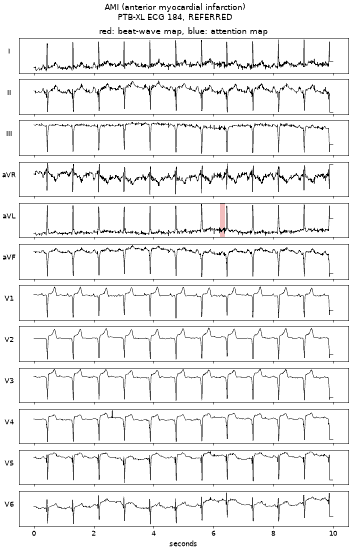

ECG 189 | REFERRED | ensemble score +7.75 (threshold +0.24) | finding score +0.76 (threshold 3.34) | PVC score -0.12 (switch 1.65)
           | explained by the attention map (blue): II 7.4-7.6 s


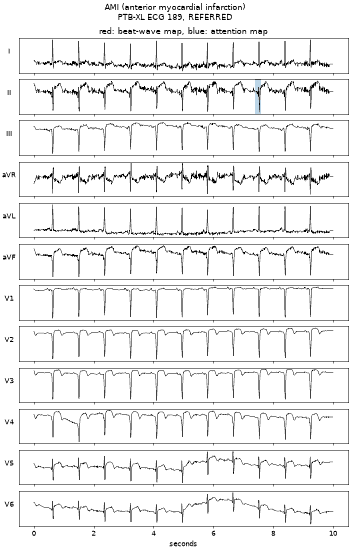

In [14]:
show_group("AMI (anterior myocardial infarction)", 2)

Both anterior infarcts are referred by the ensemble score (+7.02 and +7.75). ECG 184 has a PVC score of 1.71, just above the switch of 1.65, so the beat-wave map explains it, with one mark at the P wave of the beat at 6.46 s in aVL, not an anterior lead. ECG 189 goes to the attention map, which marks II at 7.4-7.6 s, also not an anterior lead.

**Inferior myocardial infarction.** Damage to the lower wall, expected in II, III and aVF (the attention map sees only II of these).

ECG 8 | not referred | ensemble score -2.42 (threshold +0.24) | finding score -0.05 (threshold 3.34) | PVC score -0.05 (switch 1.65)


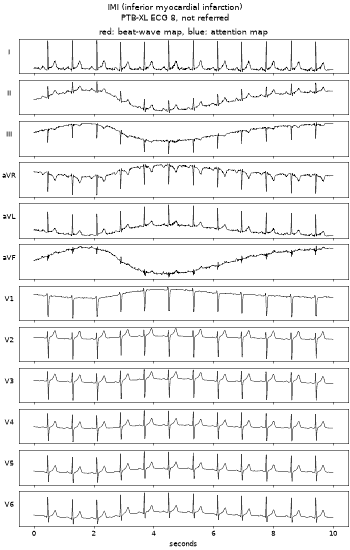

ECG 155 | not referred | ensemble score -0.31 (threshold +0.24) | finding score +1.28 (threshold 3.34) | PVC score +1.28 (switch 1.65)


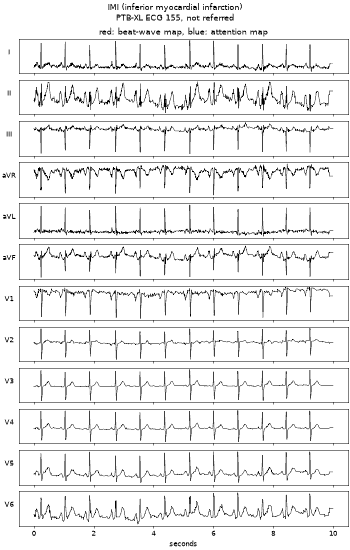

In [15]:
show_group("IMI (inferior myocardial infarction)", 2)

Neither inferior infarct is referred: ECG 8 has an ensemble score of -2.42 and ECG 155 of -0.31, both below +0.24. Over the whole group, 83% are referred (section 4).

**Anterior ischemia.** Too little blood to the front wall: ST depression or T-wave inversion in the front leads.

ECG 554 | REFERRED | ensemble score +2.08 (threshold +0.24) | finding score +0.82 (threshold 3.34) | PVC score +0.82 (switch 1.65)
           | explained by the attention map (blue): V5 2.6-2.8 s


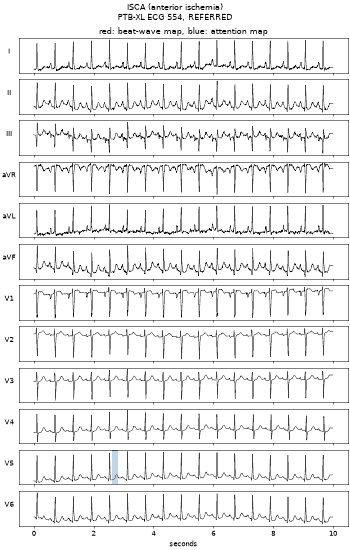

ECG 1427 | REFERRED | ensemble score +5.41 (threshold +0.24) | finding score +1.67 (threshold 3.34) | PVC score +1.67 (switch 1.65)
           | explained by the beat-wave map (red): V3 QRS of the beat at 9.27 s


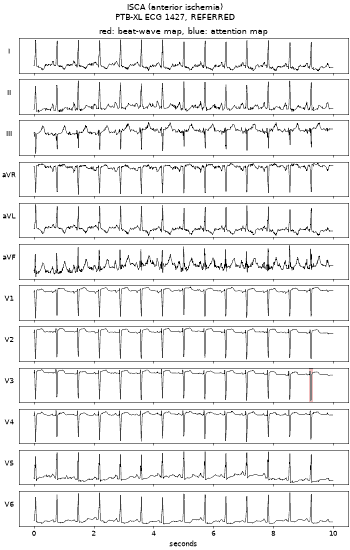

In [16]:
show_group("ISCA (anterior ischemia)", 2)

Both are referred. ECG 554 is explained by the attention map in V5 at 2.6-2.8 s. ECG 1427 has a PVC score of 1.67, just above the switch, so the beat-wave map explains it: the QRS of the beat at 9.27 s in V3.

**Non-specific ST/T change.** Changes of the recovery part of the beat without a specific cause.

ECG 127 | not referred | ensemble score -0.89 (threshold +0.24) | finding score +1.35 (threshold 3.34) | PVC score +0.26 (switch 1.65)


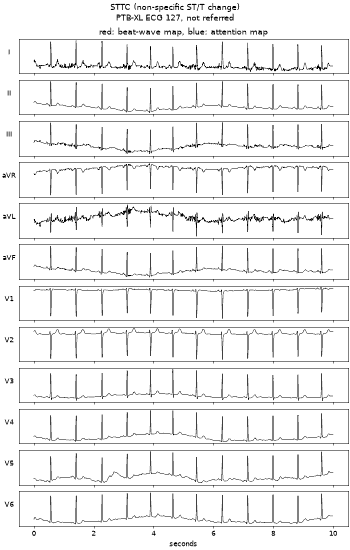

ECG 217 | REFERRED | ensemble score +0.86 (threshold +0.24) | finding score +1.54 (threshold 3.34) | PVC score +1.54 (switch 1.65)
           | explained by the attention map (blue): V2 0.6-0.8 s


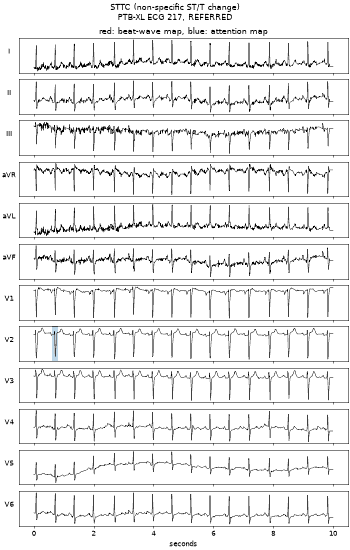

In [17]:
show_group("STTC (non-specific ST/T change)", 2)

ECG 127 is not referred (ensemble score -0.89). ECG 217 is referred (+0.86) and explained by the attention map in V2 at 0.6-0.8 s. This group has the lowest referral rate, 68%.

**Left ventricular hypertrophy.** A thickened left ventricle: tall QRS waves, often with ST-T changes.

ECG 30 | not referred | ensemble score -0.69 (threshold +0.24) | finding score +0.49 (threshold 3.34) | PVC score -0.18 (switch 1.65)


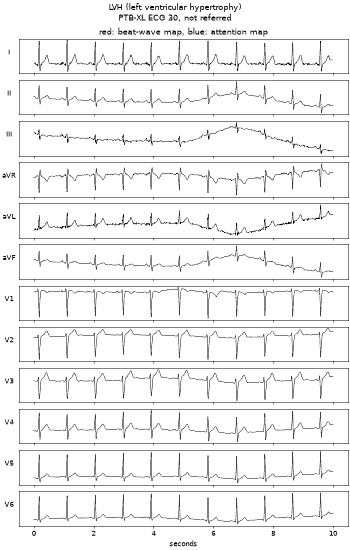

ECG 414 | REFERRED | ensemble score +9.16 (threshold +0.24) | finding score +0.08 (threshold 3.34) | PVC score +0.08 (switch 1.65)
           | explained by the attention map (blue): I 8.8-9.0 s


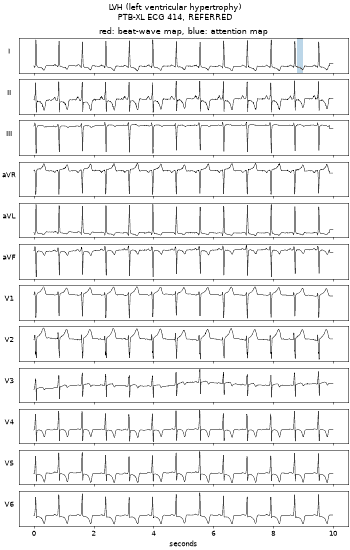

In [18]:
show_group("LVH (left ventricular hypertrophy)", 2)

ECG 30 is not referred (ensemble score -0.69). ECG 414 is referred with an ensemble score of +9.16 and explained by the attention map in lead I at 8.8-9.0 s.

**Complete left bundle branch block.** The left conduction branch is blocked, so every QRS is wide.

ECG 287 | REFERRED | ensemble score +8.29 (threshold +0.24) | finding score +6.94 (threshold 3.34) | PVC score +6.94 (switch 1.65)
           | explained by the beat-wave map (red): V1 ST of the beat at 9.10 s


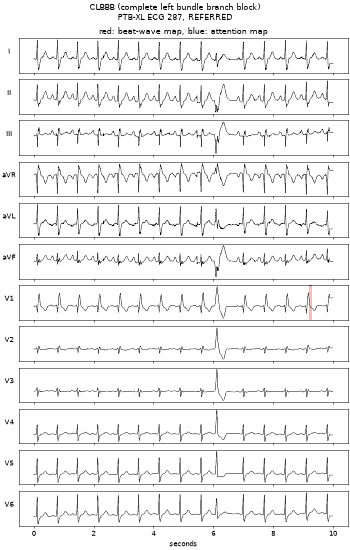

ECG 545 | REFERRED | ensemble score +8.02 (threshold +0.24) | finding score +0.93 (threshold 3.34) | PVC score +0.89 (switch 1.65)
           | explained by the attention map (blue): I 8.8-9.0 s


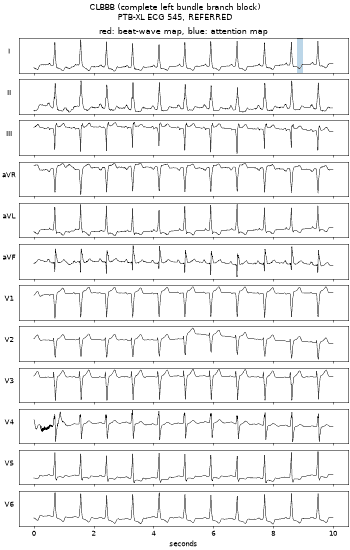

In [19]:
show_group("CLBBB (complete left bundle branch block)", 2)

ECG 287 is the PVC example above. ECG 545 (PVC score 0.89) is explained by the attention map in lead I at 8.8-9.0 s. All 40 complete left bundle branch blocks are referred (section 4).

**Complete right bundle branch block.** The right branch is blocked: a wide QRS with a double peak (rSR') in V1.

ECG 1123 | REFERRED | ensemble score +7.42 (threshold +0.24) | finding score +0.51 (threshold 3.34) | PVC score +0.51 (switch 1.65)
           | explained by the attention map (blue): V1 2.6-2.8 s


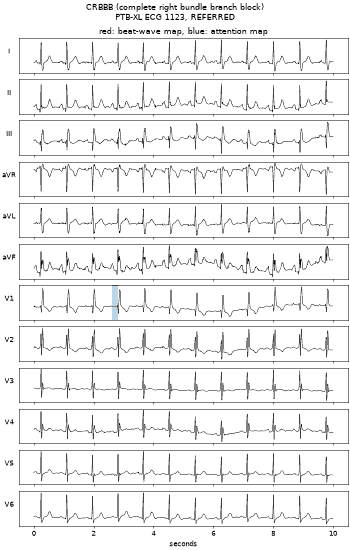

ECG 1478 | REFERRED | ensemble score +7.00 (threshold +0.24) | finding score -0.96 (threshold 3.34) | PVC score -1.23 (switch 1.65)
           | explained by the attention map (blue): V1 0.8-1.0 s; V1 1.0-1.2 s; V1 2.6-2.8 s; V1 4.4-4.6 s; V1 5.4-5.6 s; V1 7.2-7.4 s; and 1 more


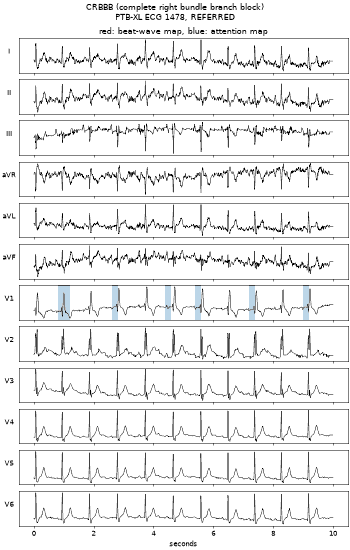

In [20]:
show_group("CRBBB (complete right bundle branch block)", 2)

Both are referred and explained by the attention map, both in V1: ECG 1123 at 2.6-2.8 s, and ECG 1478 in seven patches across the recording.

**Incomplete right bundle branch block.** A milder version, common in athletes.

ECG 483 | REFERRED | ensemble score +6.42 (threshold +0.24) | finding score +2.14 (threshold 3.34) | PVC score +2.14 (switch 1.65)
           | explained by the beat-wave map (red): V6 QRS of the beat at 5.21 s; V6 QRS of the beat at 5.79 s; V6 QRS of the beat at 6.38 s; V6 QRS of the beat at 6.96 s; V6 QRS of the beat at 7.54 s; V6 QRS of the beat at 8.11 s; and 2 more


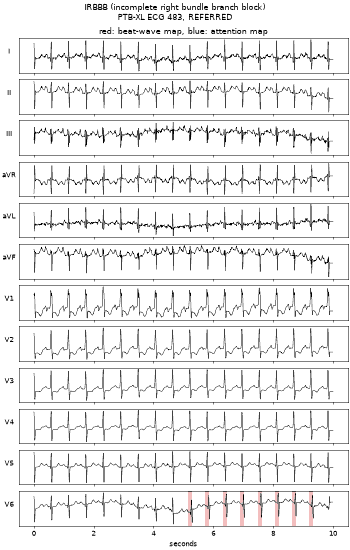

ECG 823 | REFERRED | ensemble score +3.43 (threshold +0.24) | finding score +11.92 (threshold 3.34) | PVC score +11.92 (switch 1.65)
           | explained by the beat-wave map (red): II P of the beat at 3.47 s; II QRS of the beat at 3.47 s; aVR P of the beat at 3.47 s; aVR QRS of the beat at 3.47 s; V1 P of the beat at 3.47 s; V1 QRS of the beat at 3.47 s; and 19 more


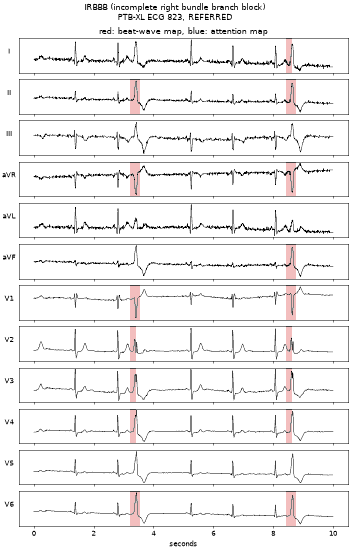

In [21]:
show_group("IRBBB (incomplete right bundle branch block)", 2)

ECG 483 (PVC score 2.14) is explained by the beat-wave map: the QRS in V6 of eight beats from 5.21 s on, the same lead and wave beat after beat. ECG 823 has a PVC score of 11.92 and 25 marks; the six listed are the P and QRS windows of the beat at 3.47 s in II, aVR and V1.

**Fascicular block.** A smaller branch is blocked, which shifts the direction (axis) of every QRS.

ECG 41 | REFERRED | ensemble score +3.13 (threshold +0.24) | finding score +1.07 (threshold 3.34) | PVC score -0.30 (switch 1.65)
           | explained by the attention map (blue): II 2.4-2.6 s; II 3.2-3.4 s; II 4.0-4.2 s; II 9.0-9.2 s; II 9.8-10.0 s


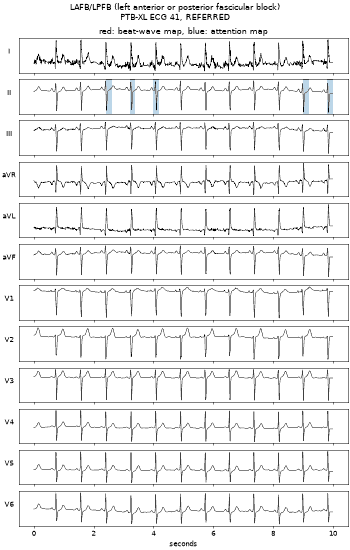

ECG 238 | REFERRED | ensemble score +2.28 (threshold +0.24) | finding score +2.51 (threshold 3.34) | PVC score +2.51 (switch 1.65)
           | explained by the beat-wave map (red): III QRS of the beat at 7.28 s


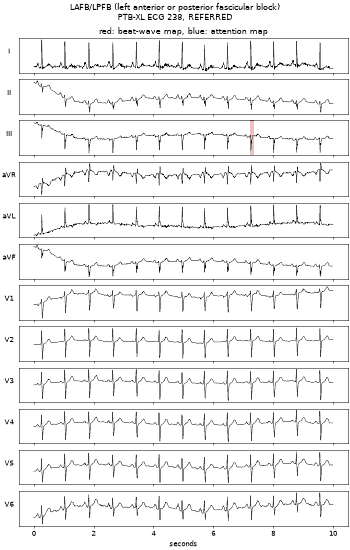

In [22]:
show_group("LAFB/LPFB (left anterior or posterior fascicular block)", 2)

Both are referred. ECG 41 is explained by the attention map in five patches of lead II. ECG 238 (PVC score 2.51) is explained by the beat-wave map: the QRS of the beat at 7.28 s in III.

**Atrioventricular block.** The signal from the atria to the ventricles is delayed: a long PR interval, or dropped beats.

ECG 234 | REFERRED | ensemble score +6.77 (threshold +0.24) | finding score +1.50 (threshold 3.34) | PVC score +1.50 (switch 1.65)
           | explained by the attention map (blue): V4 6.2-6.4 s


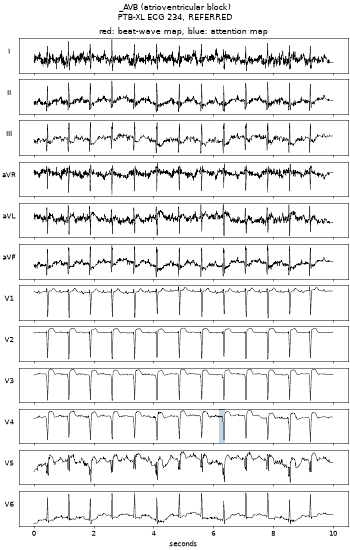

ECG 524 | REFERRED | ensemble score +1.72 (threshold +0.24) | finding score +1.30 (threshold 3.34) | PVC score +1.30 (switch 1.65)
           | explained by the attention map (blue): V5 9.8-10.0 s


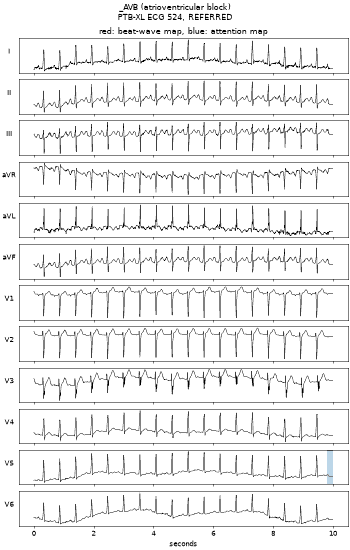

In [23]:
show_group("_AVB (atrioventricular block)", 2)

Both are referred and explained by the attention map: ECG 234 in V4 at 6.2-6.4 s, ECG 524 in V5 at 9.8-10.0 s.

**Wolff-Parkinson-White.** An extra pathway lets the ventricles start early: a short PR and a slurred start of the QRS in every beat. The WPW finding head was trained for it.

ECG 6240 | REFERRED | ensemble score +8.96 (threshold +0.24) | finding score +6.49 (threshold 3.34) | PVC score +3.22 (switch 1.65)
           | explained by the beat-wave map (red): III QRS of the beat at 0.56 s; aVL QRS of the beat at 0.56 s; III QRS of the beat at 1.32 s; aVL QRS of the beat at 1.32 s; III QRS of the beat at 2.08 s; aVL QRS of the beat at 2.08 s; and 22 more


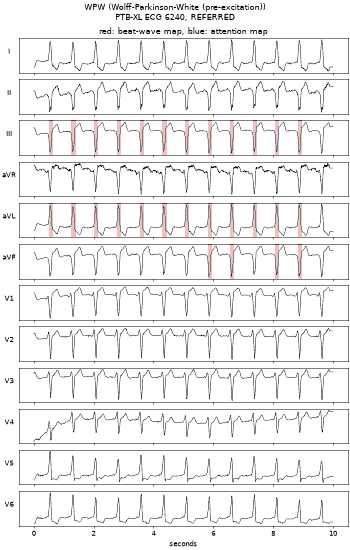

ECG 9699 | REFERRED | ensemble score +6.98 (threshold +0.24) | finding score +8.05 (threshold 3.34) | PVC score +2.00 (switch 1.65)
           | explained by the beat-wave map (red): aVF QRS of the beat at 7.10 s


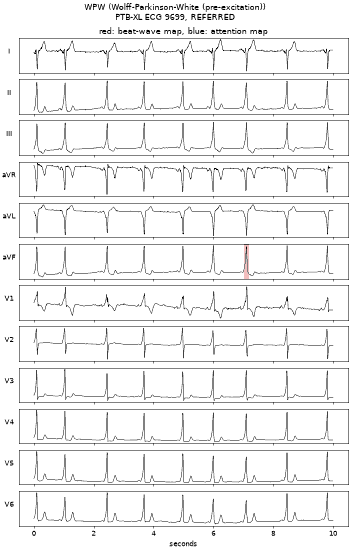

In [24]:
show_group("WPW (Wolff-Parkinson-White (pre-excitation))", 2)

Both are referred, and both have a PVC score above the switch (3.22 and 2.00), so the beat-wave map explains them. ECG 6240 gets the QRS in III and aVL beat after beat from 0.56 s on (28 marks). ECG 9699 gets one mark, the QRS of the beat at 7.10 s in aVF. Their finding scores (6.49 and 8.05) come from the WPW head, but only the PVC score chooses the map.

## 7. Do the live numbers equal the saved ones?

For every ECG shown above: the largest difference between this notebook's CPU result and the saved values,
and whether the referral decision is the same as with the saved scores.

In [25]:
checked = pd.DataFrame(checks).drop_duplicates("ECG")
print(f"{len(checked)} ECGs checked")
largest = checked[["ensemble score", "PVC score", "WPW score", "beat-wave scores", "attention map"]].max()
print("largest differences:", largest.map("{:.1e}".format).to_dict())
print("same referral decision for all:", bool(checked["same decision"].all()))

29 ECGs checked
largest differences: {'ensemble score': '1.0e-05', 'PVC score': '4.0e-06', 'WPW score': '2.0e-06', 'beat-wave scores': '0.0e+00', 'attention map': '3.2e-05'}
same referral decision for all: True


Over the 29 different ECGs scored live, the ensemble score differs from the saved value by at most 1.0e-05, the PVC score by 4.0e-06, the WPW score by 2.0e-06 and the attention map by 3.2e-05, and the beat-wave scores are identical. Every referral decision is the same as with the saved scores. The live encoders ran on the CPU; the saved scores came from a graphics card.

## 8. How well it works on other data

**Screening.** The pipeline was compared with its two earlier versions on SPH, a Chinese hospital set that
none of them was trained on (it was looked at while building them, so it is not a final test). Thresholds
came from 200 of that hospital's own normal ECGs, with the referral rule at 5%, averaged over 200 random
choices of those normals. v2 used only the xECG encoder; v3 added the ECG-JEPA summary to the readout; v4 is
the pipeline shown here. "Athlete-criteria abnormal" ECGs are those an international guideline for young
athletes calls abnormal. "Other" ECGs are neither normal nor abnormal by the label: slow or fast sinus
rhythm, early atrial beats and similar.

In [26]:
summary_saved = {(row["pipeline"], row["rule"], row["m"], row["budget"]): row
                 for row in result046["summary"]}
contrasts_saved = {(row["contrast"], row["rule"], row["m"], row["budget"], row["outcome"]): row
                   for row in result046["contrasts"]}
outcomes = {"composite": "athlete-criteria abnormal caught", "binary_positive": "abnormal (label) caught",
            "normal": "normals referred", "other": "'other' ECGs referred"}
rows = {}
for outcome, label in outcomes.items():
    rows[label] = {pipeline: summary_saved[(pipeline, "combined_50", 200, 0.05)][outcome]["mean"]
                   for pipeline in ("v2", "v3", "v4")}
    found = contrasts_saved[("v4_minus_v3", "combined_50", 200, 0.05, outcome)]
    rows[label]["v4 - v3 [95% interval]"] = (f"{found['difference']:+.4f} "
                                             f"[{found['ci'][0]:+.4f}, {found['ci'][1]:+.4f}]")
display(pd.DataFrame(rows).T.round(4))

,v2,v3,v4,v4 - v3 [95% interval]
athlete-criteria abnormal caught,0.789314,0.797319,0.809383,"+0.0121 [+0.0082, +0.0161]"
abnormal (label) caught,0.767642,0.776865,0.790628,"+0.0138 [+0.0094, +0.0183]"
normals referred,0.054543,0.057358,0.058171,"+0.0008 [-0.0017, +0.0032]"
'other' ECGs referred,0.22319,0.24875,0.274741,"+0.0260 [+0.0168, +0.0352]"


**Explanation.** On the PTB-XL development ECGs referred by the referral rule (with v3's readout, a
close relative of the ensemble score): "hit" is the share of the 73 PVC ECGs with an automatically detected
premature beat whose explanation lands on that beat, and "chance" what a random piece would give. The
*anterior contrast* is how much more often anterior infarcts are explained in V1-V4 than inferior infarcts
are; a positive value means the map points to the right part of the heart. The last two columns count the
referred infarcts that the switch sends to the beat-wave map. The "focal switch" is an alternative switch
that was tried: it switches when one beat stands out from the others, without the PVC score.

In [27]:
case = result049["cases"]["combined_50_q0.975"]
names = {"pvc_switch": "PVC switch (used here)", "U_B": "beat-wave map alone",
         "attention_jepa": "attention map alone", "focal_switch": "focal switch (alternative)"}
rows = {}
for arm, label in names.items():
    found = case["maps"][arm]
    hmc, anterior = found["hit_minus_chance"], found["lead_contrast"]["anterior"]
    rows[label] = {"hit": found["hit_rate"], "chance": found["chance_rate"],
                   "hit - chance [95%]": f"{hmc['value']:+.3f} [{hmc['ci_low']:+.3f}, {hmc['ci_high']:+.3f}]",
                   "anterior contrast [95%]": (f"{anterior['value']:+.3f} "
                                               f"[{anterior['ci_low']:+.3f}, {anterior['ci_high']:+.3f}]")}
    sent = case["sent_to_U_B"].get(arm)
    for region in ("anterior", "inferior"):
        total = found["infarct_ecgs"][region]
        rows[label][f"{region} infarcts to beat-wave map"] = f"{sent[region]} of {total}" if sent else ""
display(pd.DataFrame(rows).T.round(3))
print(f"referred: {case['referred']} ECGs")

,hit,chance,hit - chance [95%],anterior contrast [95%],anterior infarcts to beat-wave map,inferior infarcts to beat-wave map
PVC switch (used here),0.931507,0.197158,"+0.734 [+0.674, +0.787]","+0.183 [+0.059, +0.302]",68 of 136,47 of 116
beat-wave map alone,0.931507,0.197158,"+0.734 [+0.674, +0.787]","+0.031 [-0.099, +0.162]",,
attention map alone,0.027397,0.146575,"-0.119 [-0.156, -0.076]","+0.179 [+0.058, +0.290]",,
focal switch (alternative),0.424658,0.167841,"+0.257 [+0.158, +0.365]","+0.170 [+0.042, +0.288]",19 of 136,11 of 116


referred: 816 ECGs


## Summary: what works, what does not, and what it costs

**What works.**

- On the hospital set, v4 caught 0.809 of the athlete-criteria abnormal ECGs against 0.797 for v3 (+0.0121 [+0.0082, +0.0161]), while referring about the same share of normals (5.8% against 5.7%).
- Every PVC ECG of the development set is referred (section 4). With the PVC switch, the explanation is on the premature beat in 93% of the PVC ECGs with a detected premature beat, as with the beat-wave map alone, and the attention map's anterior contrast is kept (+0.183, against +0.031 for the beat-wave map alone).
- The whole pipeline runs on the CPU: one ECG took well under a second here, plot included (section 3), and the live scores equal the saved ones to within 3.2e-5.

**What does not, and the costs.**

- **"Other" ECGs.** v4 refers 27.5% of the ECGs that are neither normal nor abnormal by the label (slow or fast sinus rhythm, early atrial beats), against 24.9% for v3 and 22.3% for v2. At a student clinic many of these would be healthy students.
- **Infarcts explained by the rhythm map.** The PVC switch is not specific: it sends 68 of 136 referred anterior infarcts and 47 of 116 referred inferior infarcts to the beat-wave map. Anterior infarct 184 was explained by a P wave in aVL. The focal switch sent far fewer (19 and 11) but put the explanation on the premature beat in only 42% of PVC ECGs.
- **Misses.** 4 of the 22 non-PVC cardiopathy examples were not referred: inferior infarcts 8 and 155, ST/T change 127 and hypertrophy 30. Non-specific ST/T changes are referred least (68%).
- **The marks are coarse.** Attention marks are 0.2 s patches in 8 leads, and some examples were marked in a lead where the finding is not expected (anterior infarct 189 in II). This notebook does not compare the marks with a cardiologist's reading.
- **The thresholds here come from PTB-XL's healthy development ECGs.** A clinic would set them on its own normal ECGs, so its referral rates would differ.

## 9. Where these numbers come from

- The pipeline's specification: [pipeline v4](../docs/pipeline-v4.md).
- The screening comparison of section 8 and the saved ensemble scores and attention networks:
  [Experiment 046](../docs/experiment-046-pipeline-v4-results.md).
- The PVC switch, its threshold and the maps' red thresholds:
  [Experiment 048](../docs/experiment-048-pvc-switch-results.md).
- The explanation table of section 8 (with the referral rule) and the saved WPW scores:
  [Experiment 049](../docs/experiment-049-focal-switch-results.md).
- The beat-wave map and its saved scores: [Experiment 042](../docs/experiment-042-lead-wave-maps-results.md);
  the attention network and its saved maps: [Experiment 043](../docs/experiment-043-ann-heads-results.md);
  the readout and finding heads: [Experiment 044](../docs/experiment-044-pipeline-v3-results.md);
  CPU timing: [CPU inference timing](../docs/inference-timing-cpu.md).